In [1]:
import requests
import pandas as pd
import time
import os
import getpass
import matplotlib.pyplot as plt
import seaborn as sns

# 1. INPUT TOKEN SECARA AMAN (Tidak tersimpan di kode)
print("Masukkan GitHub Personal Access Token Anda:")
GITHUB_TOKEN = getpass.getpass()
HEADERS = {'Authorization': f'token {GITHUB_TOKEN}'}
REPO = 'pandas-dev/pandas'
BASE_URL = f'https://api.github.com/repos/{REPO}/issues'

Masukkan GitHub Personal Access Token Anda:


In [2]:
# 2. FUNGSI DATA FETCHING (Paginasi API)
def fetch_github_issues(pages=15):
    data = []
    print(f"Memulai fetching {pages} halaman dari {REPO}...")
    for page in range(1, pages + 1):
        params = {'state': 'closed', 'per_page': 100, 'page': page}
        response = requests.get(BASE_URL, headers=HEADERS, params=params)
        
        if response.status_code != 200:
            print(f"Error fetching page {page}. Rate limit mungkin habis: {response.json()}")
            break
            
        issues = response.json()
        if not issues:
            break
            
        for issue in issues:
            is_pr = 'pull_request' in issue
            # Filter label jika ada (berguna untuk uji hipotesis Anggota D)
            labels = [label['name'].lower() for label in issue.get('labels', [])]
            issue_type = 'bug' if any('bug' in l for l in labels) else ('enhancement' if any('enhancement' in l for l in labels) else 'other')

            data.append({
                'id': issue['id'],
                'number': issue['number'],
                'is_pr': is_pr,
                'type': issue_type, # bug, enhancement, or other
                'state': issue['state'],
                'created_at': issue['created_at'],
                'closed_at': issue['closed_at']
            })
        
        print(f"Halaman {page} selesai. Total baris: {len(data)}")
        time.sleep(1) # Jeda aman agar tidak di-banned GitHub API
        
    return pd.DataFrame(data)

# Eksekusi pengambilan 1500 baris data (15 halaman)
df_raw = fetch_github_issues(pages=15)
if df_raw.empty:
    print("Data kosong! Proses dihentikan agar tidak terjadi error. Silakan cek token atau koneksi Anda.")
else:
    os.makedirs('../data/raw', exist_ok=True)
    df_raw.to_csv('../data/raw/raw_dataset.csv', index=False)
    print("Data mentah berhasil disimpan di data/raw/raw_dataset.csv")

Memulai fetching 15 halaman dari pandas-dev/pandas...
Halaman 1 selesai. Total baris: 100
Halaman 2 selesai. Total baris: 200
Halaman 3 selesai. Total baris: 300
Halaman 4 selesai. Total baris: 400
Halaman 5 selesai. Total baris: 500
Halaman 6 selesai. Total baris: 600
Halaman 7 selesai. Total baris: 700
Halaman 8 selesai. Total baris: 800
Halaman 9 selesai. Total baris: 900
Halaman 10 selesai. Total baris: 1000
Halaman 11 selesai. Total baris: 1100
Halaman 12 selesai. Total baris: 1200
Halaman 13 selesai. Total baris: 1300
Halaman 14 selesai. Total baris: 1400
Halaman 15 selesai. Total baris: 1500
Data mentah berhasil disimpan di data/raw/raw_dataset.csv


In [3]:
# 3. DATA CLEANING & TRANSFORMATION
print("\nMemulai proses pembersihan data...")
df = pd.read_csv('../data/raw/raw_dataset.csv')
df['created_at'] = pd.to_datetime(df['created_at'])
df['closed_at'] = pd.to_datetime(df['closed_at'])
df['resolution_days'] = (df['closed_at'] - df['created_at']).dt.total_seconds() / (24 * 3600)

# Hapus data dengan nilai null pada kolom krusial atau waktu resolusi negatif/0
df_clean = df.dropna(subset=['created_at', 'closed_at', 'resolution_days'])
df_clean = df_clean[df_clean['resolution_days'] > 0]

os.makedirs('../data/clean', exist_ok=True)
df_clean.to_csv('../data/clean/dataset.csv', index=False)
print(f"Data bersih disimpan! Sisa baris data valid: {len(df_clean)}")


Memulai proses pembersihan data...
Data bersih disimpan! Sisa baris data valid: 1500


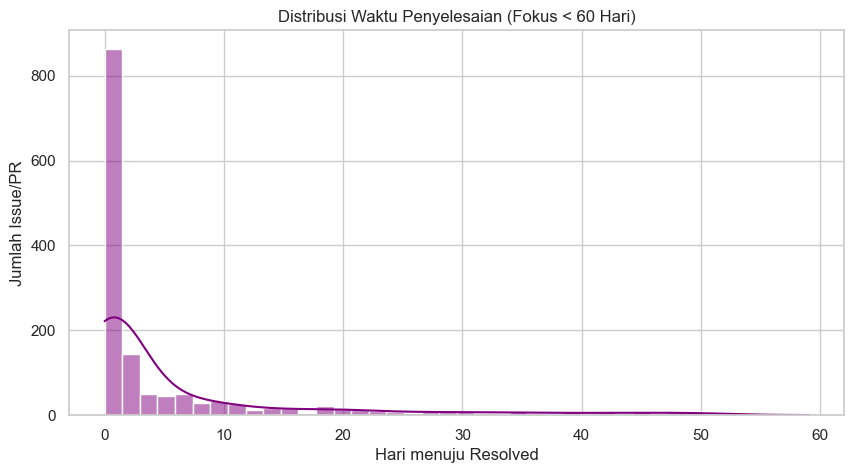

C:\Users\Darren CW\AppData\Local\Temp\ipykernel_30008\2674272541.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean[df_clean['type'].isin(['bug', 'enhancement'])], x='type', palette='Set2')


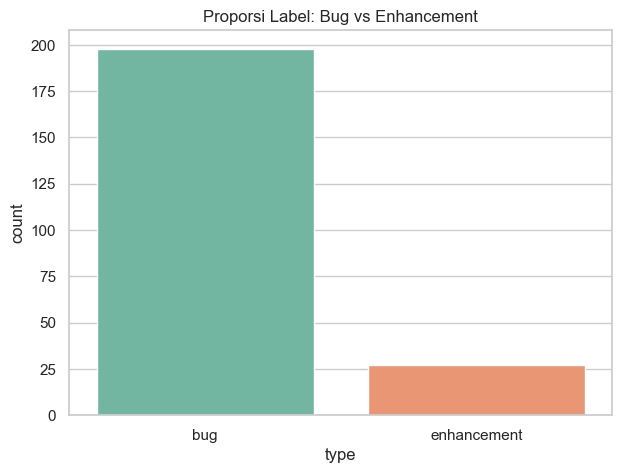

In [4]:
# 4. EXPLORATORY DATA ANALYSIS (EDA)
sns.set_theme(style="whitegrid")

# Plot 1: Distribusi Waktu
plt.figure(figsize=(10, 5))
sns.histplot(data=df_clean[df_clean['resolution_days'] < 60], x='resolution_days', bins=40, kde=True, color='purple')
plt.title('Distribusi Waktu Penyelesaian (Fokus < 60 Hari)')
plt.xlabel('Hari menuju Resolved')
plt.ylabel('Jumlah Issue/PR')
plt.show()

# Plot 2: Perbandingan Bug vs Enhancement
plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean[df_clean['type'].isin(['bug', 'enhancement'])], x='type', palette='Set2')
plt.title('Proporsi Label: Bug vs Enhancement')
plt.show()